## Data Exploration

Start by exploring the data.

1. What is the shape of the data
2. What do the images look like?
3. Are there outliers that should be removed?
4. Are the class labels imbalanced?
5. Finally, compute mean and standard deviation.

In [25]:
import sys
from google.colab import drive
drive.mount("/content/drive")
PROJECT_ROOT = "/content/drive/MyDrive/Projects/MMSEN"
sys.path.insert(0, PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import h5py
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.data import PCamDataset

Get the PCamDataset from Kaggle

In [8]:
!kaggle datasets download -d andrewmvd/metastatic-tissue-classification-patchcamelyon

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/metastatic-tissue-classification-patchcamelyon
License(s): CC0-1.0
100% 7.47G/7.47G [01:32<00:00, 86.9MB/s]



In [9]:
!unzip metastatic-tissue-classification-patchcamelyon.zip

Archive:  metastatic-tissue-classification-patchcamelyon.zip
  inflating: Labels/Labels/camelyonpatch_level_2_split_test_y.h5  
  inflating: Labels/Labels/camelyonpatch_level_2_split_train_y.h5  
  inflating: Labels/Labels/camelyonpatch_level_2_split_valid_y.h5  
  inflating: Metadata/Metadata/test_metadata.csv  
  inflating: Metadata/Metadata/train_metadata.csv  
  inflating: Metadata/Metadata/valid_metadata.csv  
  inflating: camelyonpatch_level_2_split_train_mask/camelyonpatch_level_2_split_train_mask.h5  
  inflating: pcam/test_split.h5      
  inflating: pcam/training_split.h5  
  inflating: pcam/validation_split.h5  


In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Explore the shape of the Data

In [12]:
with h5py.File('pcam/training_split.h5', 'r') as f:
  print(list(f.keys()))
  for key in f.keys():
    print(key, f[key].shape)

['x']
x (262144, 96, 96, 3)


In [13]:
with h5py.File('Labels/Labels/camelyonpatch_level_2_split_train_y.h5', 'r') as f:
  print(list(f.keys()))
  for key in f.keys():
    print(key, f[key].shape)

['y']
y (262144, 1, 1, 1)


### View a subset of Images with there corresponding labels

In [ ]:
# define a transform
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

# load the training data
train_data = PCamDataset(
    'pcam/training_split.h5', 
    'Labels/Labels/camelyonpatch_level_2_split_train_y.h5', 
    transform=transform,
    filter=[]
)

# pass it to the dataloader
train_loader = DataLoader(
    train_data,
    batch_size=128,
    num_workers=2,
    pin_memory=False
)

# get a sample batch
sample_batch = next(iter(train_loader))

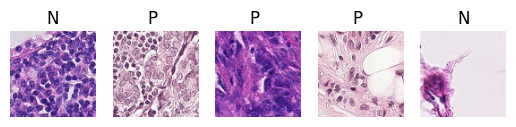

In [17]:
# create a plot with 5 subplots visualizing the images from the sample batch

fig, axs = plt.subplots(1, 5)

for i in range(5):
  axs[i].imshow(sample_batch[0][i].permute(1, 2, 0))

  # Remove axis ticks
  axs[i].set_xticks([])
  axs[i].set_yticks([])

  # Optional: remove the whole axis frame
  axs[i].axis('off')

  # Add title
  axs[i].set_title('P 'if sample_batch[1][i].item() else 'N')

plt.show()

### Look for Outliers

In [19]:
outliers = []

for i, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
    x = batch[0]

    # check for images with minimal variation in intensity
    diff = x.amax(dim=(2,3)) - x.amin(dim=(2,3))  # (B, C)
    mask = torch.all(diff < 1e-6, dim=1)

    if mask.any():
        for idx in mask.nonzero(as_tuple=True)[0]:
            outliers.append(i * train_loader.batch_size + idx.item())

outliers

100%|██████████| 2048/2048 [08:57<00:00,  3.81it/s]


[32889, 121632, 250861, 260375]

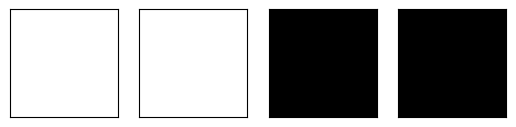

In [20]:
# Visualize the outliers

fig, axs = plt.subplots(1, 4)

for i, idx in enumerate(outliers):

  with h5py.File('pcam/training_split.h5', 'r') as f:
    image = f['x'][idx]

  axs[i].imshow(image)
  axs[i].set_xticks([])
  axs[i].set_yticks([])

plt.show()

### Compute Mean and Standard Deviation, check for Class imbalances

In [ ]:
# define a transform
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

# load the training data
train_data = PCamDataset(
    'pcam/training_split.h5', 
    'Labels/Labels/camelyonpatch_level_2_split_train_y.h5', 
    transform=transform,
    filter=[32889, 121632, 250861, 260375] # now filter out the bad samples
)

# pass it to the dataloader
train_loader = DataLoader(
    train_data,
    batch_size=128,
    num_workers=2,
    pin_memory=False
)

In [24]:
running_mean = torch.zeros(3).to(device)
running_M2 = torch.zeros(3).to(device)
count = 0
positive_count = 0

for batch in tqdm(train_loader):

    # compute mean and std
    x = batch[0].to(device, non_blocking=True)

    # flatten batch: (B, C, H, W) -> (B, C, H*W)
    B, C, H, W = x.shape
    x = x.view(B, C, -1)

    batch_count = torch.tensor(x.numel() // C, device=device, dtype=torch.float32)

    # compute mean and std over the batch
    batch_mean = x.mean(dim=(0, 2))
    batch_var = x.var(dim=(0, 2), unbiased=False)

    delta = batch_mean - running_mean

    total_count = count + batch_count

    # update running mean and M2
    running_mean += delta * batch_count / total_count

    running_M2 += batch_var * batch_count + (delta**2) * count * batch_count / total_count

    count = total_count

    # count class labels
    y = batch[1].to(device, non_blocking=True)
    positive_count += torch.sum(y).item()

# final stats
mean = running_mean
std = torch.sqrt(running_M2 / count)
negative_count = len(train_data) - positive_count

mean, std, positive_count, negative_count

100%|██████████| 2048/2048 [09:10<00:00,  3.72it/s]


(tensor([0.7008, 0.5384, 0.6916]),
 tensor([0.2350, 0.2774, 0.2129]),
 131072,
 131072)

The dataset is already perfectly balanced